# Evaluation metrics using [scikit-learn](https://sklearn.org/) and [nltk](http://www.nltk.org/)

Course: Evaluation of NLP systems

Lecturer: Brielen Madureira

February 10, 2021

University of Potsdam

In [15]:
import matplotlib.pyplot as plt
import math
import nltk
import numpy as np
import sklearn
import itertools

We'll start with some metrics in [sklearn.metrics](https://sklearn.org/modules/model_evaluation.html) and then cover some in [nltk modules](https://www.nltk.org/api/nltk.html).

## Accuracy, Precision, Recall and F1

In [2]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

Suppose this is the output of your POS tagger and the corresponding gold standard. It's a type of multiclass classification problem (but the metrics are used for binary classification as well).

In [3]:
output = ['N', 'V', 'N', 'Adj', 'Adv', 'N', 'V', 'Adv', 'V', 'Adj', 'V', 'Adv']
gold = ['V', 'V', 'N', 'Adv', 'Adv', 'N', 'V', 'Adj', 'V', 'Adj', 'V', 'N']

my_labels = list(set(gold))
print(my_labels)

['Adj', 'V', 'Adv', 'N']


### Accuracy

In [4]:
acc = accuracy_score(gold, output)
print(acc)

0.6666666666666666


Number of observations correctly classified:

In [5]:
n_correct = accuracy_score(gold, output, normalize=False)
print(n_correct)

8


### Precision

In [6]:
# argument labels only needed if we want the results in a particular order
prec = precision_score(gold, output, labels=my_labels, average=None) # separate per class

for label, p in zip(my_labels, prec):
    print(label, '\t', p)
    
avr_prec = precision_score(gold, output, average='macro') #  mean, same as sum(prec)/len(prec)
print(avr_prec)

Adj 	 0.5
V 	 1.0
Adv 	 0.3333333333333333
N 	 0.6666666666666666
0.625


### Recall

In [7]:
recall = recall_score(gold, output, labels=my_labels, average=None) # separate per class

for label, r in zip(my_labels, recall):
    print(label, '\t', r)
    
avr_rec = recall_score(gold, output, average='weighted') # weighted mean (based on proportion of each class in gold)
print(avr_rec)

Adj 	 0.5
V 	 0.8
Adv 	 0.5
N 	 0.6666666666666666
0.6666666666666666


### F-Score

In [8]:
f1_each = f1_score(gold, output, average=None) # separate per class
print(f1_each)

f1 = f1_score(gold, output, average='macro') #  mean, same as sum(f1_each)/len(f1_each)
print(f1)

[0.5        0.4        0.66666667 0.88888889]
0.6138888888888889


All at once:

In [10]:
precision_recall_fscore_support(gold, output, average=None)

(array([0.5       , 0.33333333, 0.66666667, 1.        ]),
 array([0.5       , 0.5       , 0.66666667, 0.8       ]),
 array([0.5       , 0.4       , 0.66666667, 0.88888889]),
 array([2, 2, 3, 5]))

### Utilities

In [11]:
print(classification_report(gold, output))

              precision    recall  f1-score   support

         Adj       0.50      0.50      0.50         2
         Adv       0.33      0.50      0.40         2
           N       0.67      0.67      0.67         3
           V       1.00      0.80      0.89         5

    accuracy                           0.67        12
   macro avg       0.62      0.62      0.61        12
weighted avg       0.72      0.67      0.69        12



In [12]:
cmatrix = confusion_matrix(gold, output, labels=my_labels)
print(cmatrix)

[[1 0 1 0]
 [0 4 0 1]
 [1 0 1 0]
 [0 0 1 2]]


In [13]:
# adapted from # https://sklearn.org/auto_examples/model_selection/plot_confusion_matrix.html#sphx-glr-auto-examples-model-selection-plot-confusion-matrix-py
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    
    bottom, top = plt.ylim()
    plt.setp(plt.gca(), ylim=(bottom+0.5, top-0.5))

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

np.set_printoptions(precision=2)

Confusion matrix, without normalization
[[1 0 1 0]
 [0 4 0 1]
 [1 0 1 0]
 [0 0 1 2]]


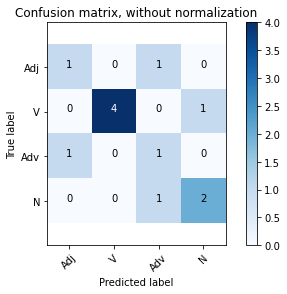

In [16]:
plt.figure()
plot_confusion_matrix(cmatrix, classes=my_labels,
                      title='Confusion matrix, without normalization')
plt.show()

## ROC and AUC

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import sklearn.metrics as metrics

When we have binary classification, e.g. binary sentiment analysis (positive or negative), and our model outputs a score, we can compute the so-called Receiver Operating Characteristic curves. Let's assume we have scores in $[0,1]$ so that the score is the probability of a given observation be assigned to class 1.

In [18]:
output = [0.42, 0.39, 0.98, 0.21, 0.67, 0.19, 0.56, 0.43, 0.54, 0.22, 0.58, 0.79]
gold = [0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1]

In [19]:
# false positive rates, true positive rates, thresholds
fpr, tpr, thresholds = roc_curve(gold, output)

In [23]:
auc = roc_auc_score(gold, output)
print(auc)

0.8285714285714285


If score > thresholds, class = 1, else class = 0. It tries many thresholds and computes the corresponding false positive rate and true positive rate.

In [21]:
print(fpr)
print(tpr)
print(thresholds) 

[0.   0.   0.   0.29 0.29 0.57 0.57 1.  ]
[0.  0.2 0.6 0.6 0.8 0.8 1.  1. ]
[1.98 0.98 0.67 0.56 0.54 0.42 0.39 0.19]


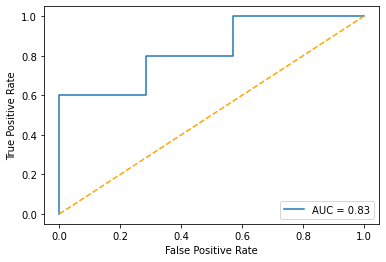

In [22]:
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc)
display.plot() 
plt.plot([0, 1], [0, 1], color='orange', linestyle='--')
plt.show()  

## Adjusted Rand Score

The [Rand Index](https://en.wikipedia.org/wiki/Rand_index) adjusted for chance. It's metric to score the quality of a clustering method. The labels are not classes, they represent different clusters. In these case, what matters is not only assigning the correct 'class' to each element but also making sure that elements of the same type end up in the same cluster. The labels themselves do not matter.

This metric ranges from -1 to 1. 0 means a random clustering, 1 means a perfect clustering. The metric is symmetric $ars(a,b)=ars(b,a)$.

In [26]:
from sklearn.metrics import adjusted_rand_score

Suppose we have a list of 12 documents grouped into 3 groups: mystery, adventure and sci-fi. Each index correponds to one document.

- A: Sci-fi = {0, 1, 3, 6, 9}
- B: Mystery = {2, 7, 11}
- C: Adventure = {4, 5, 8, 10}

Let's say we tried three clustering algorithms and their output was:

Cluster |     System 1      |     System 2     | System 3 |
 ------ | -------------     | -------------    | ------------- |
   A    | {2, 3, 8, 9, 10}  | {0, 3, 9}        | {4, 5, 8, 10}  |
   B    | {5, 6, 11}        | {2, 6, 7, 11}    | {0, 1, 3, 6, 9}  |
   C    | {0, 1, 4, 7}      | {1, 4, 5, 8, 10} | {2, 7, 11}  |

In [24]:
# the position in the list correspond to the text id
output_1 = ['C', 'C', 'A', 'A','C', 'B', 'B', 'C', 'A', 'A', 'A', 'B']
output_2 = ['A', 'C', 'B', 'A', 'C', 'C', 'B', 'B', 'C', 'A', 'C', 'B']
output_3 = ['B', 'B', 'C', 'B', 'A', 'A', 'B', 'C', 'A', 'B', 'A', 'C']

gold = ['A', 'A', 'B', 'A', 'C', 'C', 'A', 'B', 'C', 'A', 'C', 'B']

In [27]:
adjusted_rand_score(output_1, gold)

-0.18253079507278835

In [28]:
adjusted_rand_score(output_2, gold)

0.48264277715565507

In [29]:
adjusted_rand_score(output_3, gold)

1.0

Remember: what counts is the quality of the clusters, not their labels! It's used, for example, when we use an unsupervised method even though we have golden annotation.

## Mean Squared/Absolute Error

Used when we have continuous variables. It sums the average of the differences between the predicted valued and the golden values (using either squared or absolute values, otherwise positive and negative errors would cancel each other out) and divide it by the number of observations.

For example, assum we have a sample of an independent variable $x$ and the value of their respective dependent variable $y$. We want to model their relation as a linear function $y=f(x)=ax+b$, where $a$ and $b$ are coefficients.

The error would be:

$MSE(y_{pred}, y_{true}) = \frac{1}{N} \sum \limits_{i=1}^{N} (y_{true_i} - y_{pred_i})^2$

where $N$ is the number of observations.

MSE is always $>=0$. It's 0 when there are no errors (a perfect model).

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.datasets import make_regression

In [31]:
x = [0.5, 0.78, 0.97, 1.3, 1.8, 2.1, 2.9, 3.3, 3.6]

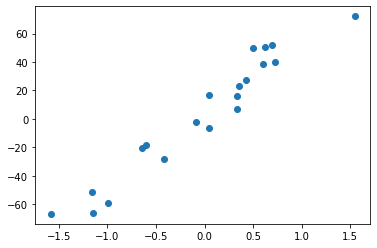

In [32]:
X, y, coef = make_regression(20, 1, n_informative=3, n_targets=1, bias=2.5, noise=8, coef=True, random_state=4)

plt.plot(X, y, 'o')

In [ ]:
print(coef)

Let's say we have tried to fit the data with different methods and got two models. Which model is better, $y = 48x + 4$ or $y = 55x + 1$?

In [33]:
m1 = [48*x + 4 for x in X]
m2 = [55*x + 1 for x in X]

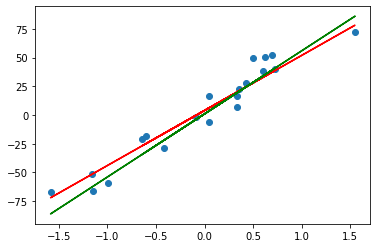

In [34]:
plt.plot(X, y, 'o')
plt.plot(X, m1, color='red')
plt.plot(X, m2, color='green')

The MSE and MAE of each model are:

In [35]:
print(mean_squared_error(y, m1)) 
print(mean_squared_error(y, m2))

112.95407642729751
125.52623033457049


It's common to report the square root of MSE:

In [36]:
print(math.sqrt(mean_squared_error(y, m1))) 
print(math.sqrt(mean_squared_error(y, m2)))

10.627985530066246
11.20384890716447


In [37]:
print(mean_absolute_error(y, m1))
print(mean_absolute_error(y, m2))

8.753175963511406
9.487416165516233


## Cross-entropy loss

Also known as [log loss](https://scikit-learn.org/stable/modules/model_evaluation.html#log-loss), it's used when the output of a model is a probability distribution over classes. It's a non-negative number, and the closer to 0, the better the output.

In [38]:
from sklearn.metrics import log_loss

In [39]:
gold = [0, 2, 1] # three classes

# an list/array of lists/array, each is a probability distribution over the labels (corresponding position indexes)
pred_probs_1 = [[0.98, 0.01, 0.01], [0.17, 0.13, 0.80], [0.10, 0.70, 0.20]] # common output
pred_probs_2 = [[1.00, 0.00, 0.00], [0.00, 0.00, 1.00], [0.00, 1.00, 0.00]] # theoretically 100% correct predictions 
pred_probs_3 = [[0.00, 0.00, 1.00], [0.00, 1.00, 0.00], [1.00, 0.00, 0.00]] # theoretically 100% incorrect predictions

In [40]:
log_loss(gold, pred_probs_1) # normalize=True by default

0.23177712745826215

In [41]:
log_loss(gold, pred_probs_2) # is not exactly 0 due to eps=1e-15 by default

2.1094237467877998e-15

In [42]:
log_loss(gold, pred_probs_3)

34.538776394910684

## Cosine similarity

The cosine of the angle between two vectors expressed as the normalized dot product between them. It ranges from -1 to 1. When it's -1, the vectors are exact opposites. When it's 0, the vectors are orthogonal. When it's 1, the vectors are the same (in position, not magnitude).

$cossim(u, v) = \frac{<u,v>}{\left\|u\right\| \left\|v\right\|}$

Visualization in two dimensions:

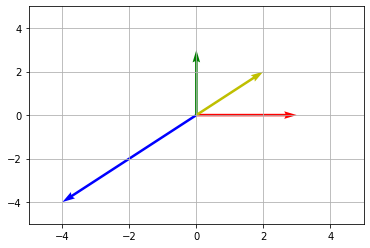

In [43]:
origin = np.array([[0, 0, 0, 0],[0, 0, 0, 0]])
plt.quiver(*origin, [3, -4, 0, 2], [0, -4, 3, 2], color=['r','b','g', 'y'], angles='xy', scale_units='xy', scale=1)
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.grid(b=True, which='major')
plt.show()

In [44]:
from sklearn.metrics.pairwise import cosine_similarity

In [45]:
v_1 = np.array([[0.3, 0.7, -1.3, 4.5, -2.5]])
v_2 = np.array([[2.2, -0.4, -1.7, 1.6, -0.9]])

In [46]:
print(cosine_similarity(v_1, v_2))

[[0.67]]


In [47]:
print(cosine_similarity(v_1, v_1))

[[1.]]


In [48]:
print(cosine_similarity(v_1, 3*v_1)) # magnitude does not matter

[[1.]]


In [49]:
print(cosine_similarity(v_1, -2*v_1)) # magnitude does not matter

[[-1.]]


## Cohen's Kappa

A statistic used for calculating the inter-annotator agreement. The [Cohen's Kappa coefficient](https://en.wikipedia.org/wiki/Cohen%27s_kappa) ranges between -1 and 1, where 1 is a perfect agreement.

In [50]:
from sklearn.metrics import cohen_kappa_score

Suppose two annotators annotated the Named Entities in a sentence.

In [56]:
annotator_1 = ['company', 'none', 'person', 'person', 'company', 'none', 'place', 'company', 'none', 'place']
annotator_2 = ['person', 'none', 'place', 'company', 'none', 'none', 'place', 'none', 'person', 'none']
annotator_3 = ['person', 'none', 'none', 'company', 'none', 'none', 'place', 'none', 'person', 'none']

In [52]:
cohen_kappa_score(annotator_1, annotator_2)

0.054054054054053946

In [57]:
cohen_kappa_score(annotator_3, annotator_2)

0.8412698412698413

## BLEU

Let's check [*nltk*'s implementation](https://www.nltk.org/_modules/nltk/translate/bleu_score.html) of the BLEU score, used in Machine Translation. It ranges from 0 to 1, and 1 means a perfect translation (in terms of this metric). This metric was proposed in [this paper](https://www.aclweb.org/anthology/P02-1040.pdf).

In [58]:
from nltk.translate import bleu_score

In [59]:
# human generated translations for 'Ontem nós fizemos a tarefa de casa muito bem.'
reference_1 = "Yesterday we did our homework very well .".split()
reference_2 = "We did the housework very well yesterday .".split()
reference_3 = "We did the homework yesterday very well .".split()

# output of two different models
model_1 = "Yesterday we made the work of house very good .".split()
model_2 = "We did homework yesterday very well .".split()

In [60]:
bleu_score.sentence_bleu([reference_1, reference_2, reference_3], model_1)

/Users/brie/opt/anaconda3/envs/pytorch/lib/python3.7/site-packages/nltk/translate/bleu_score.py:523: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/Users/brie/opt/anaconda3/envs/pytorch/lib/python3.7/site-packages/nltk/translate/bleu_score.py:523: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


7.241926111174567e-155

Selecting a smoothing method to deal with $P(ngram)=0$.

In [61]:
bleu_score.sentence_bleu([reference_1, reference_2, reference_3], model_1, 
                         smoothing_function=bleu_score.SmoothingFunction().method1)

0.056122223243057295

In [62]:
bleu_score.sentence_bleu([reference_1, reference_2, reference_3], model_2)

0.6129752413741056

Customizing the weights for the ngrams:

In [63]:
bleu_score.sentence_bleu([reference_1, reference_2, reference_3], model_2, weights=(0.5, 0.25, 0.25, 0))

0.7289545183625967

One way to fool this metric:

In [64]:
# clearly in the wrong order, but BLEU score even better than model_2
model_3 = "homework yesterday very well . We did the ".split() 
bleu_score.sentence_bleu([reference_1, reference_2, reference_3], model_3)

0.691441569283882

In this example we evaluated a single sentence, but we normally need to estimate BLEU in corpus level. For that, use ``bleu_score.corpus_bleu``.

## Edit (Levenshtein) Distance

The [Edit Distance](https://en.wikipedia.org/wiki/Edit_distance) captures the minimum number of edits (deletions, insertions, substitutions) necessary to turn one string into another one. Used, for example, in ASR systems.

In [67]:
from nltk.metrics.distance import edit_distance

In [68]:
gold = "the space flight"
output_1 = "the spicy fight"
output_2 = "despotic mice"

In [69]:
# transform output_1 into gold
edit_distance(output_1, gold)

3

In [70]:
edit_distance(output_2, gold)

12

## Pointwise Mutual Information

[PMI](https://en.wikipedia.org/wiki/Pointwise_mutual_information) is a measure of association between two random variables (here words). It is 0 when the two random variables are independent, negative when they 'repel' each other and positive when they usually happen together. Let's see an example with bigrams.

In [71]:
# getting a corpus
from nltk.corpus import shakespeare

In [ ]:
#nltk.download('shakespeare')

In [72]:
bigram_measures = nltk.collocations.BigramAssocMeasures()
finder = nltk.collocations.BigramCollocationFinder.from_words(shakespeare.words('dream.xml'))

Getting the bigrams and their respective PMI:

In [73]:
for i in finder.score_ngrams(bigram_measures.pmi):
    print(i)

(('&', 'c'), 14.394596668240993)
((",--'", 'Ladies'), 14.394596668240993)
(('Contagious', 'fogs'), 14.394596668240993)
(('Dramatis', 'Personae'), 14.394596668240993)
(('Faintness', 'constraineth'), 14.394596668240993)
(('Gently', 'entwist'), 14.394596668240993)
(('Immediately', 'provided'), 14.394596668240993)
(('Impatient', 'answers'), 14.394596668240993)
(('MIDSUMMER', 'NIGHT'), 14.394596668240993)
(('Mistress', 'Squash'), 14.394596668240993)
(('Muses', 'mourning'), 14.394596668240993)
(('Painted', 'butterflies'), 14.394596668240993)
(('Reason', 'becomes'), 14.394596668240993)
(('Saint', 'Valentine'), 14.394596668240993)
(('Shine', 'comforts'), 14.394596668240993)
(('Sisters', 'Three'), 14.394596668240993)
(('Thessalian', 'bulls'), 14.394596668240993)
(('Thorny', 'hedgehogs'), 14.394596668240993)
(('Thracian', 'singer'), 14.394596668240993)
(('Weaving', 'spiders'), 14.394596668240993)
(('amorous', 'Phillida'), 14.394596668240993)
(('antique', 'fables'), 14.394596668240993)
(('audacio

(('their', 'brows'), 8.75074047846627)
(('their', 'children'), 8.75074047846627)
(('their', 'continents'), 8.75074047846627)
(('their', 'fathers'), 8.75074047846627)
(('their', 'heads'), 8.75074047846627)
(('their', 'hips'), 8.75074047846627)
(('their', 'increase'), 8.75074047846627)
(('their', 'intents'), 8.75074047846627)
(('their', 'jangling'), 8.75074047846627)
(('their', 'leathern'), 8.75074047846627)
(('their', 'parents'), 8.75074047846627)
(('their', 'practised'), 8.75074047846627)
(('their', 'purpose'), 8.75074047846627)
(('their', 'season'), 8.75074047846627)
(('their', 'shames'), 8.75074047846627)
(('their', 'spheres'), 8.75074047846627)
(('their', 'unbreathed'), 8.75074047846627)
(('their', 'wits'), 8.75074047846627)
(('their', 'wormy'), 8.75074047846627)
(('their', 'fears'), 8.750740478466268)
(('By', 'moonshine'), 8.722171326269496)
(('Crowns', 'him'), 8.722171326269496)
(('Feed', 'him'), 8.722171326269496)
(('Of', 'colour'), 8.722171326269496)
(('Of', 'strong'), 8.7221713

(('nearly', 'that'), 7.2756555955174855)
(('stuff', 'that'), 7.2756555955174855)
(('that', 'Hobgoblin'), 7.2756555955174855)
(('that', 'bankrupt'), 7.2756555955174855)
(('that', 'composed'), 7.2756555955174855)
(('that', 'concerns'), 7.2756555955174855)
(('that', 'costs'), 7.2756555955174855)
(('that', 'creeps'), 7.2756555955174855)
(('that', 'hinders'), 7.2756555955174855)
(('that', 'liked'), 7.2756555955174855)
(('that', 'moment'), 7.2756555955174855)
(('that', 'plays'), 7.2756555955174855)
(('that', 'scorns'), 7.2756555955174855)
(('that', 'writ'), 7.2756555955174855)
(('wretch', 'that'), 7.2756555955174855)
(('No', 'wonder'), 7.265313651296027)
(('With', 'duty'), 7.265313651296027)
(('With', 'hounds'), 7.265313651296027)
(('an', 'oath'), 7.265313651296027)
(('appear', 'When'), 7.265313651296027)
(('fair', 'blessed'), 7.265313651296027)
(('happy', 'fair'), 7.265313651296027)
(('loved', 'an'), 7.265313651296027)
(('needs', 'play'), 7.265313651296027)
(('play', 'needs'), 7.26531365129

(('early', 'to'), 6.270475356411806)
(('engaged', 'to'), 6.270475356411806)
(('enthralled', 'to'), 6.270475356411806)
(('eunuch', 'to'), 6.270475356411806)
(('fancies', 'to'), 6.270475356411806)
(('hymns', 'to'), 6.270475356411806)
(('listen', 'to'), 6.270475356411806)
(('loath', 'to'), 6.270475356411806)
(('loathing', 'to'), 6.270475356411806)
(('marshal', 'to'), 6.270475356411806)
(('meant', 'to'), 6.270475356411806)
(('minding', 'to'), 6.270475356411806)
(('observance', 'to'), 6.270475356411806)
(('offer', 'to'), 6.270475356411806)
(('ought', 'to'), 6.270475356411806)
(('page', 'to'), 6.270475356411806)
(('paradise', 'to'), 6.270475356411806)
(('paths', 'to'), 6.270475356411806)
(('piping', 'to'), 6.270475356411806)
(('prepare', 'to'), 6.270475356411806)
(('refuse', 'to'), 6.270475356411806)
(('ribbons', 'to'), 6.270475356411806)
(('ringlets', 'to'), 6.270475356411806)
(('siege', 'to'), 6.270475356411806)
(('some', 'power'), 6.270475356411806)
(('then', 'came'), 6.270475356411806)
(

(('the', 'pert'), 5.4757334309663985)
(('the', 'players'), 5.4757334309663985)
(('the', 'quern'), 5.4757334309663985)
(('the', 'rattling'), 5.4757334309663985)
(('the', 'saddest'), 5.4757334309663985)
(('the', 'sails'), 5.4757334309663985)
(('the', 'screech'), 5.4757334309663985)
(('the', 'scrip'), 5.4757334309663985)
(('the', 'scroll'), 5.4757334309663985)
(('the', 'seeing'), 5.4757334309663985)
(('the', 'sharp'), 5.4757334309663985)
(('the', 'silliest'), 5.4757334309663985)
(('the', 'sky'), 5.4757334309663985)
(('the', 'snake'), 5.4757334309663985)
(('the', 'society'), 5.4757334309663985)
(('the', 'sparrow'), 5.4757334309663985)
(('the', 'spiced'), 5.4757334309663985)
(('the', 'stomach'), 5.4757334309663985)
(('the', 'stop'), 5.4757334309663985)
(('the', 'story'), 5.4757334309663985)
(('the', 'sweetest'), 5.4757334309663985)
(('the', 'tempest'), 5.4757334309663985)
(('the', 'temple'), 5.4757334309663985)
(('the', 'third'), 5.4757334309663985)
(('the', 'tiger'), 5.4757334309663985)
((

(('You', 'may'), 4.621457461521302)
(('my', 'certain'), 4.621457461521302)
(('my', 'dog'), 4.621457461521302)
(('my', 'mistress'), 4.621457461521302)
(('my', 'modesty'), 4.621457461521302)
(('my', 'patience'), 4.621457461521302)
(('my', 'voice'), 4.621457461521302)
(('strange', 'my'), 4.621457461521302)
(('This', 'is'), 4.618398659832113)
(('Ay', 'me'), 4.613236954716333)
(('PUCK', 'Come'), 4.613236954716333)
(('PUCK', 'How'), 4.613236954716333)
(('THESEUS', 'It'), 4.613236954716333)
(('THESEUS', 'What'), 4.613236954716333)
(('THESEUS', 'Why'), 4.613236954716333)
(('am', 'gone'), 4.613236954716333)
(('could', 'not'), 4.613236954716333)
(('draw', 'me'), 4.613236954716333)
(('kiss', 'me'), 4.613236954716333)
(('loved', 'me'), 4.613236954716333)
(('me', 'On'), 4.613236954716333)
(('me', 'kiss'), 4.613236954716333)
(('me', 'seem'), 4.613236954716333)
(('me', 'wrong'), 4.613236954716333)
(('not', 'near'), 4.613236954716333)
(('away', '!'), 4.6099618226834735)
(('do', 'best'), 4.609961822683

(('swear', 'to'), 3.6855128556906482)
(('sword', 'to'), 3.6855128556906482)
(('to', 'Egeus'), 3.6855128556906482)
(('to', 'awake'), 3.6855128556906482)
(('to', 'earth'), 3.6855128556906482)
(('to', 'get'), 3.6855128556906482)
(('to', 'heaven'), 3.6855128556906482)
(('to', 'low'), 3.6855128556906482)
(('to', 'present'), 3.6855128556906482)
(('to', 'swear'), 3.6855128556906482)
(('together', 'to'), 3.6855128556906482)
(('with', 'Hermia'), 3.6835750514491554)
(('mine', '!'), 3.6803511505748716)
(('!', 'Ay'), 3.68035115057487)
(('eyes', 'must'), 3.68035115057487)
(('voice', '!'), 3.68035115057487)
(('HERMIA', 'HERMIA'), 3.6786346779858494)
(('did', 'him'), 3.6777772069110437)
(('him', 'at'), 3.6777772069110437)
(('Thisby', "'"), 3.674494947624922)
(('there', 'no'), 3.671789137071446)
(('there', 'we'), 3.671789137071446)
(('OBERON', 'That'), 3.6700828151210434)
(('That', 'would'), 3.6700828151210434)
(('a', 'lanthorn'), 3.668378508908795)
(('a', 'right'), 3.668378508908795)
(('a', 'young'),

(('eye', '-'), 2.9688562439247814)
(('d', 'look'), 2.9641441165754614)
(('have', 'look'), 2.9641441165754614)
(('in', 'this'), 2.9641441165754614)
(('she', 'be'), 2.961793811889125)
(('comes', ';'), 2.9558048156627326)
(('gone', ';'), 2.9558048156627326)
(('meet', ';'), 2.9558048156627326)
((';', 'Be'), 2.955804815662731)
(('blood', ';'), 2.955804815662731)
(('bush', ';'), 2.955804815662731)
(('flower', ';'), 2.955804815662731)
(('maid', ';'), 2.955804815662731)
(('off', ';'), 2.955804815662731)
(('show', ';'), 2.955804815662731)
(('soul', ';'), 2.955804815662731)
(('train', ';'), 2.955804815662731)
(('us', ';'), 2.955804815662731)
(('wood', ';'), 2.955804815662731)
(('hear', 'that'), 2.953727500630123)
(('For', 'you'), 2.949409344036434)
(('So', 'is'), 2.9485472615244444)
(('look', 'to'), 2.9485472615244426)
(('made', 'to'), 2.9485472615244426)
(('Athenian', "'"), 2.9475134420313402)
(('Helen', "'"), 2.9475134420313402)
(('Is', "'"), 2.9475134420313402)
(('flower', "'"), 2.94751344203

(('all', 'that'), 1.9181035908994009)
(('her', 'but'), 1.9178504643015266)
(('night', "'"), 1.9177660986372889)
(('me', 'no'), 1.9127972365752424)
(('love', 'by'), 1.9117887115143244)
((';', 'This'), 1.9114106963042783)
((':', 'As'), 1.9095221045423791)
((':', 'away'), 1.9095221045423791)
((':', 'what'), 1.9095221045423791)
(('eye', ':'), 1.9095221045423791)
(('speak', 'you'), 1.9087673595390875)
(('is', 'some'), 1.9012415467460873)
((',', 'how'), 1.9003410816960127)
(('What', ','), 1.9003410816960127)
(('thus', ','), 1.9003410816960127)
(('here', 'will'), 1.8984918889008675)
((',', 'And'), 1.8944404802563284)
(('Bottom', 'the'), 1.8907709302452425)
(('Now', 'the'), 1.8907709302452425)
(('die', 'the'), 1.8907709302452425)
(('ever', 'the'), 1.8907709302452425)
(('me', 'on'), 1.8907709302452425)
(('place', 'the'), 1.8907709302452425)
(('the', 'head'), 1.8907709302452425)
(('man', "'"), 1.888619752977771)
(('I', "'"), 1.8875896243792845)
(('say', 'I'), 1.8834617387566048)
(('?', 'This'), 

((',', 'can'), -1.375783323578224)
(('can', ','), -1.375783323578224)
(('he', '.'), -1.380859294328154)
(('it', 'the'), -1.4069096183954422)
(('you', 'the'), -1.425133377014351)
(('we', ','), -1.4439548262198052)
((',', 'on'), -1.4659811325498033)
(('I', ','), -1.4815108308434048)
((';', "'"), -1.4912784105469221)
((';', 'my'), -1.4954062961695964)
((',', 'hath'), -1.50904985444169)
(('me', "'"), -1.511918176605958)
(('s', 'the'), -1.5466343820620558)
(('!', 'and'), -1.5599631787588404)
((';', 'is'), -1.5833539954452984)
((',', 'OBERON'), -1.5915120146336612)
((',', 'would'), -1.5915120146336612)
(('would', ','), -1.5915120146336612)
(("'", 'is'), -1.5916453690766907)
(('is', '.'), -1.6162373572590845)
((':', 'a'), -1.617023709953454)
(('you', 'to'), -1.6303914515689435)
(('?', 'and'), -1.6352513060630791)
(('and', ','), -1.6619013425250593)
(('And', "'"), -1.6671964020838672)
(('and', 'is'), -1.7068045670881133)
(('is', 'and'), -1.7068045670881133)
(('he', ','), -1.725367761368453)
((

## Other utilities for evaluation

### Model selection

A method to automatically split a dataset into training and test sets.

In [74]:
from sklearn.model_selection import train_test_split, KFold

In [75]:
# getting some example data
data = sklearn.datasets.load_digits()

In [76]:
data.data.shape

(1797, 64)

In [77]:
data.target.shape

(1797,)

We can choose the proportion of the test set (or the train set with ``train_size``). ``random_state`` is a seed to ensure that the randomly generation of the datasets will be the same everytime we run the code again. ``shuffle`` can be set to ``True`` when we do not want to preserve the original order.

In [78]:
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.25, 
                                                    shuffle=True, random_state=10)

In [79]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1347, 64) (450, 64) (1347,) (450,)


### Cross validation iteractors

Let's see the K-fold method.

In [ ]:
X = data.data
y = data.target

In [80]:
kfolds = KFold(5, shuffle=True, random_state=4)

In [81]:
for train_ids, test_ids in kfolds.split(X):
    print(train_ids, test_ids)

[ 0  1  2  4  5  7  8  9 10 11 12 13 14 15 16 17] [ 3  6 18 19]
[ 1  2  3  5  6  7  8  9 10 11 12 14 15 16 18 19] [ 0  4 13 17]
[ 0  1  2  3  4  5  6  7  8  9 13 14 16 17 18 19] [10 11 12 15]
[ 0  1  3  4  5  6  8 10 11 12 13 14 15 17 18 19] [ 2  7  9 16]
[ 0  2  3  4  6  7  9 10 11 12 13 15 16 17 18 19] [ 1  5  8 14]


In a real machine learning setting, we'd have:

In [ ]:
for train_ids, test_ids in kfolds.split(X):
    
    X_train, y_train = X[train_ids], y[train_ids]
    X_test, y_test = X[test_ids], y[test_ids]
    
    # train model with current training set
    # evaluate on the current test set
    # store results of fold k

Both scikit-learn and nltk have many other useful metrics and methods. Check them out :)